In [ ]:
!apt-get update && apt-get install -y unzip

!pip install gdown albumentations tqdm nibabel opencv-python-headless matplotlib

Get:1 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]        
Get:3 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]      
Get:4 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB] 
Get:5 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]      
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1581 B]
Get:7 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:8 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]     
Get:9 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [2059 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [2929 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:13 http:/

In [ ]:
import os
import zipfile


file_id = "1ba37DJwCet6g1LhyUQC5i9wm7eHESNGw"
output_file = "liver_project.zip"

if not os.path.exists(output_file):
    print("⬇️ جاري تحميل الداتا (قد يأخذ وقتاً حسب الحجم)...")
    !gdown --id {file_id} -O {output_file}
else:
    print("✅ الملف المضغوط موجود مسبقاً.")

if os.path.exists(output_file):
    print("📦 جاري فك الضغط...")
    try:
        with zipfile.ZipFile(output_file, 'r') as zip_ref:
            zip_ref.extractall(".")
        print("🎉 تم فك الضغط بنجاح!")
        
        print("\n📂 المجلدات الموجودة الآن:")
        !ls -d */
    except zipfile.BadZipFile:
        print("❌ الملف نزل معطوب! (حاول مرة أخرى).")
else:
    print("❌ فشل التحميل! تأكد من الرابط.")

⬇️ جاري تحميل الداتا (قد يأخذ وقتاً حسب الحجم)...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ba37DJwCet6g1LhyUQC5i9wm7eHESNGw
From (redirected): https://drive.google.com/uc?id=1ba37DJwCet6g1LhyUQC5i9wm7eHESNGw&confirm=t&uuid=e0a3dbfa-9f14-4f2d-b88b-4da4f108a4a9
To: /workspace/liver_project.zip
100%|██████████████████████████████████████| 34.6G/34.6G [06:48<00:00, 84.6MB/s]
📦 جاري فك الضغط...
🎉 تم فك الضغط بنجاح!

📂 المجلدات الموجودة الآن:
liver_project/


In [ ]:
import os

root_dir = "liver_project"

print(f"📍 نستكشف داخل: {root_dir}")

for root, dirs, files in os.walk(root_dir):
    level = root.replace(root_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}📁 {os.path.basename(root)}/")
    
    if files:
        for f in files[:2]:
            print(f"{indent}    📄 {f}")
    
    if level >= 2:
        del dirs[:]

📍 نستكشف داخل: liver_project
📁 liver_project/
    📁 LiTS_Preprocessed/
        📁 Stage2_Lesion/
        📁 Stage1_Liver/
    📁 Data/
        📁 src/
        📁 LiTS/


In [ ]:
import os

stage2_path = "liver_project/LiTS_Preprocessed/Stage2_Lesion"

print(f"📍 نستكشف: {stage2_path}")

if os.path.exists(stage2_path):
    for root, dirs, files in os.walk(stage2_path):
        level = root.replace(stage2_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}📁 {os.path.basename(root)}/")
        
        if files:
            for f in files[:3]:
                print(f"{indent}    📄 {f}")
        
        if level >= 1:
            del dirs[:]
else:
    print("❌ المسار غير موجود! تأكد من الاسم.")

📍 نستكشف: liver_project/LiTS_Preprocessed/Stage2_Lesion
📁 Stage2_Lesion/
    📁 masks/
        📄 mask_99.npy
        📄 mask_98.npy
        📄 mask_97.npy
    📁 images/
        📄 image_99.npy
        📄 image_98.npy
        📄 image_97.npy


In [ ]:
import os
import numpy as np
import glob

DATA_DIR = "liver_project/LiTS_Preprocessed/Stage2_Lesion"
IMG_DIR = os.path.join(DATA_DIR, "images")

img_files = glob.glob(os.path.join(IMG_DIR, "*.npy"))
print(f"📦 عدد الملفات الموجودة: {len(img_files)}")

if len(img_files) > 0:
    sample_path = img_files[0]
    data = np.load(sample_path)
    print(f"📄 اسم الملف: {os.path.basename(sample_path)}")
    print(f"📏 أبعاد البيانات (Shape): {data.shape}")
    
    if len(data.shape) == 2:
        print("✅ النوع: 2D Slice (شريحة صورة)")
    elif len(data.shape) == 3:
        print("✅ النوع: 3D Volume (مريض كامل)")
    else:
        print("⚠️ نوع غير معروف!")
else:
    print("❌ المجلد فارغ!")

📦 عدد الملفات الموجودة: 131
📄 اسم الملف: image_99.npy
📏 أبعاد البيانات (Shape): (236, 251, 273)
✅ النوع: 3D Volume (مريض كامل)


In [10]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]


In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import cv2


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
IMAGE_SIZE = 512
DATA_DIR = "liver_project/LiTS_Preprocessed/Stage2_Lesion"

print(f"🚀 Running H-DenseUNet Phase 1 on {DEVICE}")


class LiTS_OnTheFly_Dataset(Dataset):
    def __init__(self, img_files, mask_files, transform=None):
        self.img_files = sorted(img_files)
        self.mask_files = sorted(mask_files)
        self.transform = transform
    def __len__(self):
        return len(self.img_files) * 50
    def __getitem__(self, idx):
        patient_idx = idx % len(self.img_files)
        vol_img = np.load(self.img_files[patient_idx])
        vol_mask = np.load(self.mask_files[patient_idx])
        
        slice_idx = np.random.randint(0, vol_img.shape[0])
        for _ in range(20):
            temp = np.random.randint(0, vol_img.shape[0])
            if np.sum(vol_mask[temp]) > 0:
                slice_idx = temp
                break
        
        image = vol_img[slice_idx].astype(np.float32)
        mask = vol_mask[slice_idx].astype(np.float32)
        
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image).unsqueeze(0)
            mask = torch.from_numpy(mask).long()
        return image, mask.long()


all_images = sorted(glob.glob(os.path.join(DATA_DIR, "images", "*.npy")))
all_masks = sorted(glob.glob(os.path.join(DATA_DIR, "masks", "*.npy")))
print(f"📦 Found {len(all_images)} patients.")

train_imgs = all_images[:100]
train_masks = all_masks[:100]
val_imgs = all_images[100:115]
val_masks = all_masks[100:115]

train_transform = A.Compose([
    A.Rotate(limit=15, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    ToTensorV2()
])
val_transform = A.Compose([ToTensorV2()])

train_loader = DataLoader(LiTS_OnTheFly_Dataset(train_imgs, train_masks, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(LiTS_OnTheFly_Dataset(val_imgs, val_masks, transform=val_transform), 
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


class DenseUNet169(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.base_model = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)
        self.base_model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.enc0 = nn.Sequential(self.base_model.features.conv0, self.base_model.features.norm0, self.base_model.features.relu0)
        self.pool0 = self.base_model.features.pool0
        self.denseblock1 = self.base_model.features.denseblock1
        self.transition1 = self.base_model.features.transition1
        self.denseblock2 = self.base_model.features.denseblock2
        self.transition2 = self.base_model.features.transition2
        self.denseblock3 = self.base_model.features.denseblock3
        self.transition3 = self.base_model.features.transition3
        self.denseblock4 = self.base_model.features.denseblock4
        
        self.up1 = nn.ConvTranspose2d(1664, 832, kernel_size=2, stride=2)
        self.conv1 = nn.Sequential(nn.Conv2d(832 + 1280, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True))
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = nn.Sequential(nn.Conv2d(256 + 512, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = nn.Sequential(nn.Conv2d(128 + 256, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = nn.Sequential(nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        x0 = self.enc0(x); x1 = self.pool0(x0); x1 = self.denseblock1(x1)
        x2 = self.transition1(x1); x2 = self.denseblock2(x2)
        x3 = self.transition2(x2); x3 = self.denseblock3(x3)
        x4 = self.transition3(x3); x4 = self.denseblock4(x4)
        d1 = self.up1(x4)
        if d1.shape != x3.shape: d1 = torch.nn.functional.interpolate(d1, size=x3.shape[2:])
        d1 = torch.cat((d1, x3), dim=1); d1 = self.conv1(d1)
        d2 = self.up2(d1)
        if d2.shape != x2.shape: d2 = torch.nn.functional.interpolate(d2, size=x2.shape[2:])
        d2 = torch.cat((d2, x2), dim=1); d2 = self.conv2(d2)
        d3 = self.up3(d2)
        if d3.shape != x1.shape: d3 = torch.nn.functional.interpolate(d3, size=x1.shape[2:])
        d3 = torch.cat((d3, x1), dim=1); d3 = self.conv3(d3)
        d4 = self.up4(d3)
        if d4.shape != x0.shape: d4 = torch.nn.functional.interpolate(d4, size=x0.shape[2:])
        d4 = torch.cat((d4, x0), dim=1); d4 = self.conv4(d4)
        out = self.final_up(d4)
        return self.final_conv(out)

model = DenseUNet169(n_classes=3).to(DEVICE)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        inputs = torch.softmax(inputs, dim=1)
        input_tumor = inputs[:, 2].contiguous().view(-1)
        target_tumor = (targets == 2).float().contiguous().view(-1)
        dice_tumor = (2. * (input_tumor * target_tumor).sum() + self.smooth) / (input_tumor.sum() + target_tumor.sum() + self.smooth)
        input_liver = inputs[:, 1].contiguous().view(-1)
        target_liver = (targets == 1).float().contiguous().view(-1)
        dice_liver = (2. * (input_liver * target_liver).sum() + self.smooth) / (input_liver.sum() + target_liver.sum() + self.smooth)
        return 1 - (0.4 * dice_liver + 0.6 * dice_tumor)

criterion_ce = nn.CrossEntropyLoss(weight=torch.tensor([0.1, 1.0, 5.0]).to(DEVICE))
criterion_dice = DiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()

best_val_loss = float('inf')
SAVE_NAME = "best_model_H_Dense_Phase1.pth"

print(f" Start Training (Saving to: {SAVE_NAME})...")

for epoch in range(30):
    model.train()
    running_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/30")
    
    for images, masks in loop:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = 0.5 * criterion_ce(outputs, masks) + 0.5 * criterion_dice(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            l_ce = criterion_ce(outputs, masks)
            l_dice = criterion_dice(outputs, masks)
            val_loss += (0.5 * l_ce + 0.5 * l_dice).item()
    
    avg_val = val_loss / len(val_loader)
    print(f"📉 Val Loss: {avg_val:.4f}")
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_NAME)
        print(f"💾 New Best Model Saved: {SAVE_NAME}")

print("🎉 Training Completed!")

🚀 Running H-DenseUNet Phase 1 on cuda
📦 Found 131 patients.


/tmp/ipykernel_47856/3743927945.py:157: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🔥 Start Training (Saving to: best_model_H_Dense_Phase1.pth)...


Epoch 1/30:   0%|          | 0/157 [00:00<?, ?it/s]/tmp/ipykernel_47856/3743927945.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 157/157 [01:21<00:00,  1.92it/s, loss=0.602]


📉 Val Loss: 0.4982
💾 New Best Model Saved: best_model_H_Dense_Phase1.pth


...

📉 Val Loss: 0.2485


Epoch 29/30: 100%|██████████| 157/157 [01:21<00:00,  1.93it/s, loss=0.151] 


📉 Val Loss: 0.2473


Epoch 30/30: 100%|██████████| 157/157 [01:21<00:00,  1.93it/s, loss=0.115] 


📉 Val Loss: 0.2746
🎉 Training Completed!


🚀 Loaded: best_model_H_Dense_Phase1.pth
📸 Showing results from Validation Set...


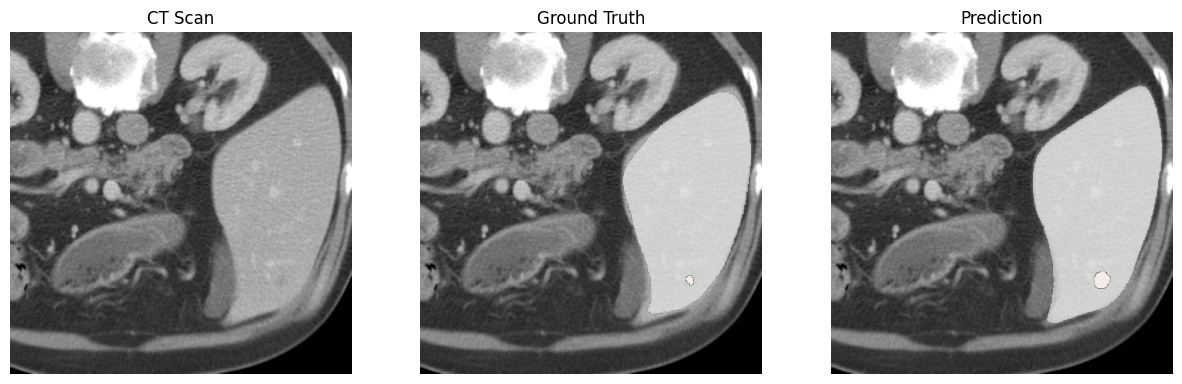

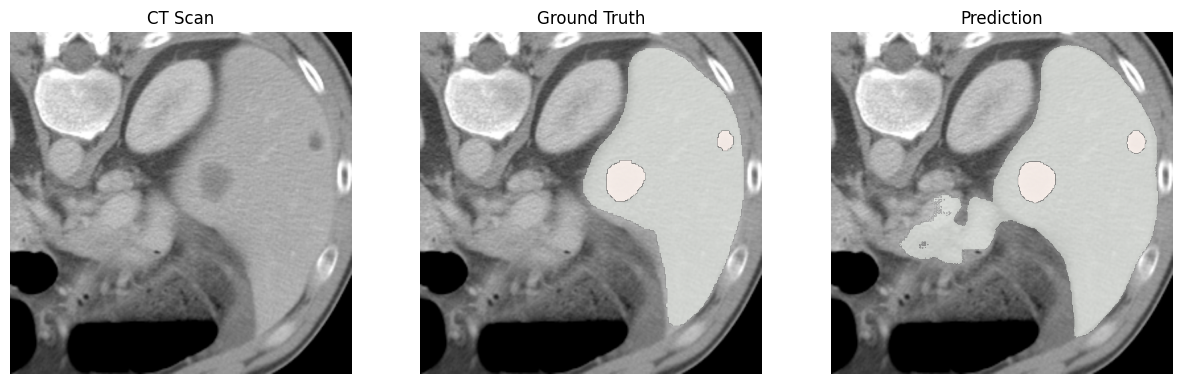

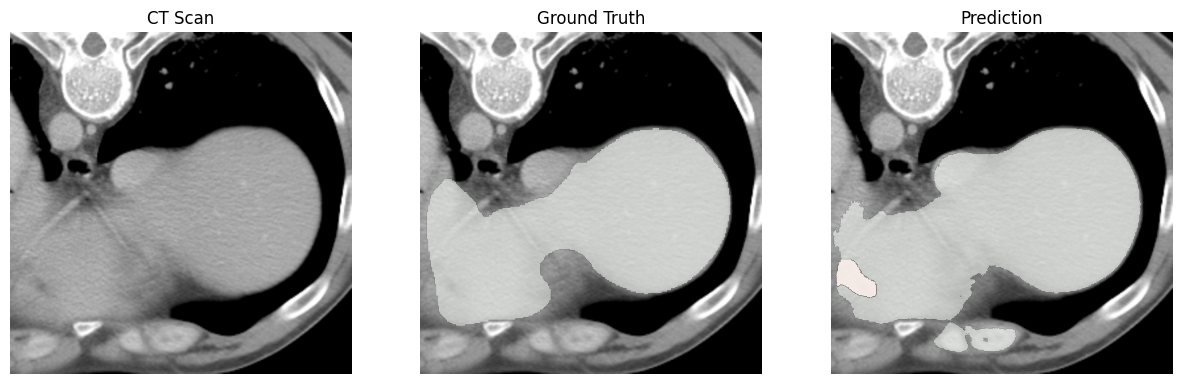

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

model = DenseUNet169(n_classes=3).to(DEVICE)
chk_path = "best_model_H_Dense_Phase1.pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path))
    print(f"🚀 Loaded: {chk_path}")
else:
    print("⚠️ Model not found!")

model.eval()

def visualize_prediction(loader, idx=None):
    dataset = loader.dataset
    if idx is None:
        for _ in range(50): 
            temp_idx = random.randint(0, len(dataset)-1)
            _, temp_mask = dataset[temp_idx]
            if torch.sum(temp_mask == 2) > 0: 
                idx = temp_idx
                break
        if idx is None: idx = random.randint(0, len(dataset)-1) 
    
    image, mask = dataset[idx]
    
   
    input_tensor = image.to(DEVICE)
    
    if input_tensor.ndim == 2: # (H, W)
        input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)
    elif input_tensor.ndim == 3: # (C, H, W)
        input_tensor = input_tensor.unsqueeze(0)
        
    # Predict
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).cpu().squeeze(0).numpy()
    
    image_np = image.numpy()
    if image_np.ndim == 3: image_np = image_np.squeeze(0)
    
    mask_np = mask.numpy()
    
    # Show
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(image_np, cmap='gray')
    ax[0].set_title("CT Scan")
    ax[0].axis('off')
    
    ax[1].imshow(image_np, cmap='gray')
    ax[1].imshow(np.ma.masked_where(mask_np!=1, mask_np), cmap='Greens', alpha=0.5)
    ax[1].imshow(np.ma.masked_where(mask_np!=2, mask_np), cmap='Reds', alpha=0.9)
    ax[1].set_title("Ground Truth")
    ax[1].axis('off')
    
    ax[2].imshow(image_np, cmap='gray')
    ax[2].imshow(np.ma.masked_where(pred!=1, pred), cmap='Greens', alpha=0.5)
    ax[2].imshow(np.ma.masked_where(pred!=2, pred), cmap='Reds', alpha=0.9)
    ax[2].set_title("Prediction")
    ax[2].axis('off')
    
    plt.show()

# عرض 3 عينات
print("📸 Showing results from Validation Set...")
for _ in range(3):
    visualize_prediction(val_loader)

In [ ]:
print("📊 Calculating Dice Score...")

liver_scores = []
tumor_scores = []

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        masks = masks.cpu().numpy()
        
        output = model(images)
        preds = torch.argmax(output, dim=1).cpu().numpy()
        
        for i in range(images.shape[0]):
            p = preds[i]
            t = masks[i]
            
            # Liver (1)
            if np.sum(t==1) > 0:
                inter = ((p==1) & (t==1)).sum()
                union = (p==1).sum() + (t==1).sum()
                liver_scores.append(2*inter / (union + 1e-5))
            
            # Tumor (2)
            if np.sum(t==2) > 0:
                inter = ((p==2) & (t==2)).sum()
                union = (p==2).sum() + (t==2).sum()
                tumor_scores.append(2*inter / (union + 1e-5))

print("\n" + "="*30)
print(f"🟢 Liver Dice: {np.mean(liver_scores)*100:.2f}%")
print(f"🔴 Tumor Dice: {np.mean(tumor_scores)*100:.2f}%")
print("="*30)

📊 Calculating Dice Score...


Evaluating: 100%|██████████| 24/24 [00:11<00:00,  2.17it/s]


🟢 Liver Dice: 90.43%
🔴 Tumor Dice: 62.68%


In [ ]:
# ==========================================
# 🛑 Final Test Evaluation (The Real Deal)
# ==========================================
import numpy as np
import torch
from tqdm import tqdm
import pandas as pd

test_imgs = all_images[115:] 
test_masks = all_masks[115:]

print(f"🔥 Testing on {len(test_imgs)} unseen patients (Test Set)...")

def evaluate_test_set(model, img_list, mask_list):
    model.eval()
    liver_scores = []
    tumor_scores = []
    
    test_dataset = LiTS_OnTheFly_Dataset(img_list, mask_list, transform=val_transform)
    test_loader_temp = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader_temp, desc="Testing"):
            images = images.to(DEVICE)
            masks = masks.cpu().numpy()
            
            output = model(images)
            preds = torch.argmax(output, dim=1).cpu().numpy()
            
            for i in range(images.shape[0]):
                p = preds[i]
                t = masks[i]
                
                # Liver (1)
                if np.sum(t==1) > 0:
                    inter = ((p==1) & (t==1)).sum()
                    union = (p==1).sum() + (t==1).sum()
                    liver_scores.append(2*inter / (union + 1e-5))
                
                # Tumor (2)
                if np.sum(t==2) > 0:
                    inter = ((p==2) & (t==2)).sum()
                    union = (p==2).sum() + (t==2).sum()
                    tumor_scores.append(2*inter / (union + 1e-5))
                    
    return np.mean(liver_scores)*100, np.mean(tumor_scores)*100

l_score, t_score = evaluate_test_set(model, test_imgs, test_masks)

print("\n" + "="*40)
print("🏆 FINAL TEST SET RESULTS (Phase 1)")
print("="*40)
print(f"🟢 Liver Dice: {l_score:.2f}%")
print(f"🔴 Tumor Dice: {t_score:.2f}%")
print("="*40)

🔥 Testing on 16 unseen patients (Test Set)...


Testing: 100%|██████████| 50/50 [00:34<00:00,  1.46it/s]


🏆 FINAL TEST SET RESULTS (Phase 1)
🟢 Liver Dice: 91.25%
🔴 Tumor Dice: 50.98%
